In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import os
from google.colab import drive
drive.mount('/content/drive')

os.chdir("drive/My Drive/Colab Data/Water/")
!ls

Mounted at /content/drive
 Communities_and_borders.jpg  'PINNs EWRA 2025'
 DataCenters_WaterStress.csv   Pontos_de_Entrega-Caudal_Instantaneo
'DataSharing_Meng et al'       temp.bin
 Others			       temp.inp
 Parete1.pdf		       temp.rpt
 Parete_DIA.jpg		       UKWIR
 Parete.inp		       WorldMap_DataCenters_WaterStress.html
 PAVIAbase.inp


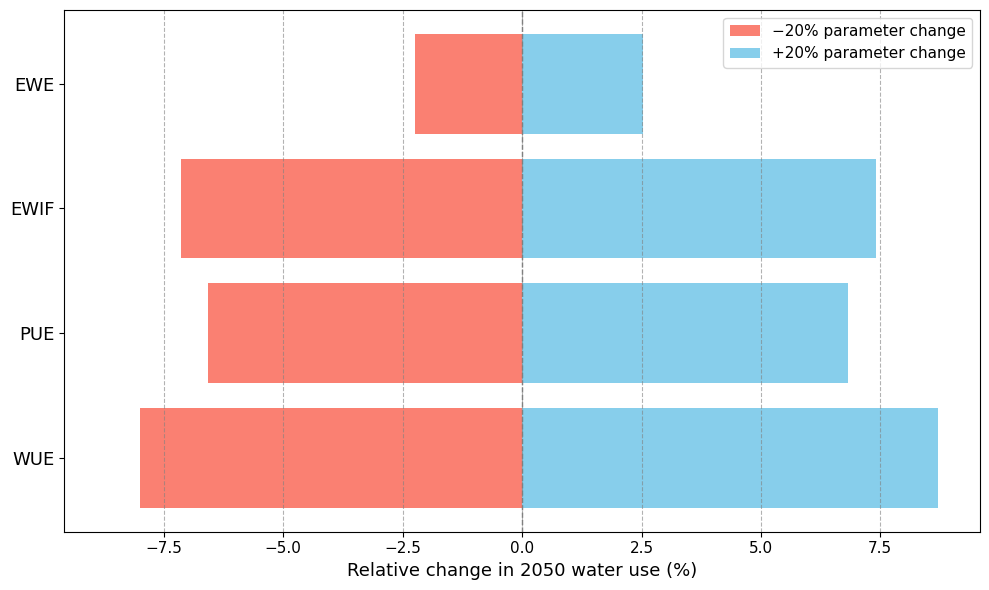

In [9]:
# ---------------------------
# SETUP: Baseline and Sensitivity Deltas
# ---------------------------

# Baseline value for 2050 water use (in billion litres/day) under BAU scenario
baseline_value = 28.11

# Estimated deltas (in billion litres/day) based on ±20% changes from full Monte Carlo simulations
deltas = {
    "WUE": [-2.25, 2.45],
    "PUE": [-1.85, 1.92],
    "EWIF": [-2.01, 2.08],
    "EWE": [-0.63, 0.71]
}

# ---------------------------
# PROCESS: Convert to Relative Changes (%)
# ---------------------------

# Compute percentage changes from the baseline for each parameter
percent_impacts = {
    k: [100 * delta[0] / baseline_value, 100 * delta[1] / baseline_value]
    for k, delta in deltas.items()
}

labels = list(percent_impacts.keys())
low_vals = [percent_impacts[k][0] for k in labels]
high_vals = [percent_impacts[k][1] for k in labels]

y_pos = np.arange(len(labels))

# ---------------------------
# PLOT: Tornado Diagram (Diverging Bar Style)
# ---------------------------

fig, ax = plt.subplots(figsize=(10, 6))
bar_thickness = 0.8

ax.barh(y_pos, low_vals, height=bar_thickness, color='salmon', align='center', label='−20% parameter change')
ax.barh(y_pos, high_vals, height=bar_thickness, color='skyblue', align='center', label='+20% parameter change')

# Add central reference line at 0
ax.axvline(0, color='gray', linewidth=1, linestyle='--')

# Add a grey grid behind the bars
ax.grid(axis='x', linestyle='--', alpha=0.6, color='grey', zorder=0) # zorder=0 puts grid behind bars

# Customise axes and labels
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=13)
ax.set_xlabel('Relative change in 2050 water use (%)', fontsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=13)
ax.legend(fontsize=11)

max_abs_val = max(abs(np.array(low_vals).min()), abs(np.array(high_vals).max()))
ax.set_xlim(-max_abs_val * 1.1, max_abs_val * 1.1)

plt.tight_layout()

# ---------------------------
# OUTPUT: Show or Save Plot
# ---------------------------

# Uncomment to save instead of display:
# plt.savefig("tornado_plot.pdf", dpi=300)

plt.show()